<a href="https://colab.research.google.com/github/akompaniiets1/API-assignment/blob/main/Lab1_ALA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1**

In [ ]:
import numpy as np

def compute_eigen(matrix):
    A = np.array(matrix, dtype=float)

    if A.shape[0] != A.shape[1]:
        raise ValueError("Matrix must be square.")

    eigenvalues, eigenvectors = np.linalg.eig(A)

    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)

    return eigenvalues, eigenvectors

In [ ]:
A = np.array([[5, 2],
              [1, 3]])

eigenvalues, eigenvectors = compute_eigen(A)

print("Matrix A:")
print(A)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Matrix A:
[[5 2]
 [1 3]]

Eigenvalues:
[5.73205081 2.26794919]

Eigenvectors:
[[ 0.9390708  -0.59069049]
 [ 0.34372377  0.80689822]]


In [ ]:
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]

    Av = A @ v
    lv = lam * v

    print(f"\nEigenvalue {i+1}: {lam}")
    print("Eigenvector:")
    print(v)
    print("A @ v =")
    print(Av)
    print("lambda * v =")
    print(lv)
    print("Are they equal? ->", np.allclose(Av, lv))


Eigenvalue 1: 5.0
Eigenvector:
[0.89442719 0.4472136 ]
A @ v =
[4.47213595 2.23606798]
lambda * v =
[4.47213595 2.23606798]
Are they equal? -> True

Eigenvalue 2: 2.0
Eigenvector:
[-0.70710678  0.70710678]
A @ v =
[-1.41421356  1.41421356]
lambda * v =
[-1.41421356  1.41421356]
Are they equal? -> True


**Task 2**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from google.colab import files

uploaded = files.upload()

Saving monkey.jpg to monkey (1).jpg


In [8]:
image_raw = imread("monkey.jpg")

print("Shape of the original image:")
print(image_raw.shape)

Shape of the original image:
(981, 736, 3)


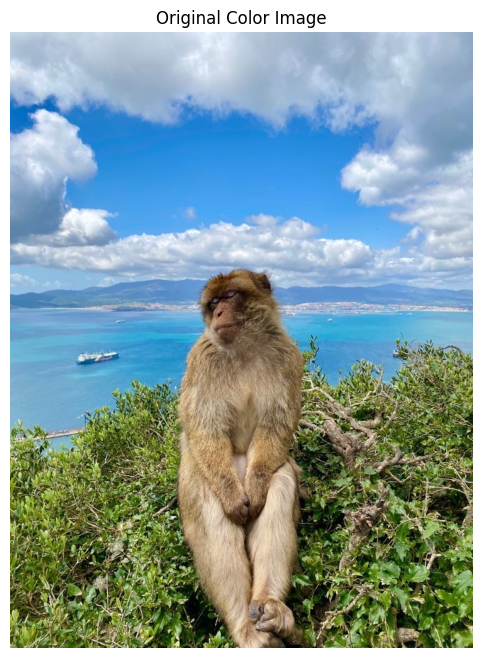

In [9]:
plt.figure(figsize=(6, 8))
plt.imshow(image_raw)
plt.title("Original Color Image")
plt.axis("off")
plt.show()

In [10]:
image_sum = image_raw.sum(axis=2)

image_bw = image_sum / image_sum.max()

print("Shape of the black and white image:")
print(image_bw.shape)

Shape of the black and white image:
(981, 736)


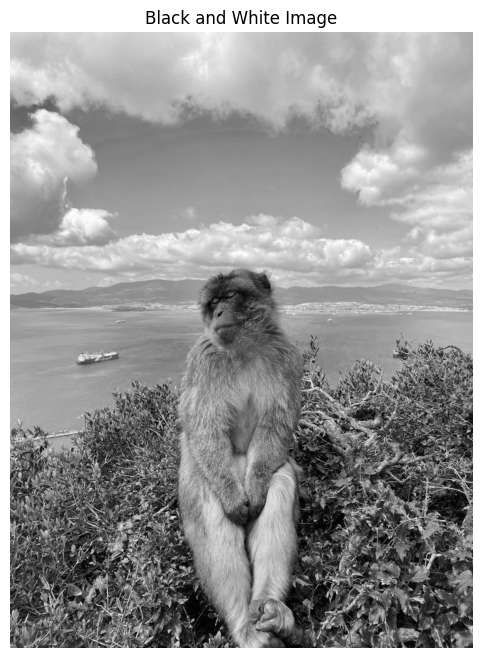

In [11]:
plt.figure(figsize=(6,8))
plt.imshow(image_bw, cmap="gray")
plt.title("Black and White Image")
plt.axis("off")
plt.show()

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(image_bw)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components needed to explain 95% variance:", num_components_95)

Number of components needed to explain 95% variance: 109


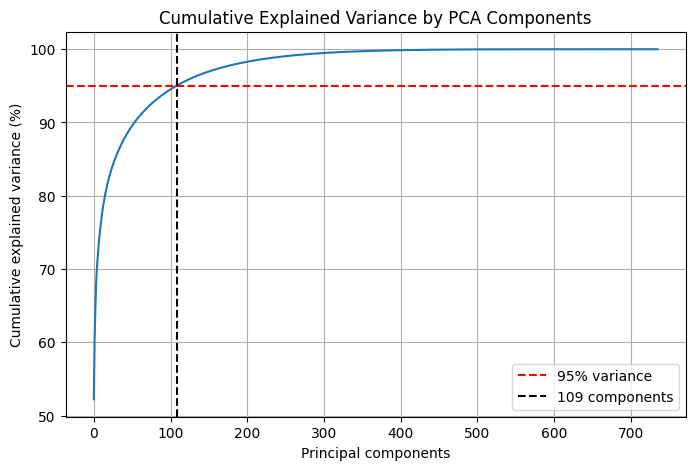

In [14]:
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance * 100)
plt.axhline(y=95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=num_components_95, color='k', linestyle='--',
            label=f'{num_components_95} components')

plt.xlabel("Principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Cumulative Explained Variance by PCA Components")
plt.legend()
plt.grid(True)
plt.show()

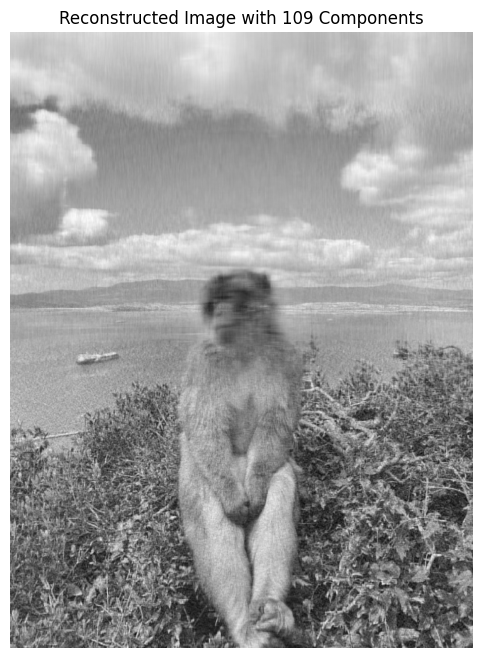

In [15]:
pca_95 = PCA(n_components=num_components_95)

image_transformed = pca_95.fit_transform(image_bw)
image_reconstructed = pca_95.inverse_transform(image_transformed)

plt.figure(figsize=(6,8))
plt.imshow(image_reconstructed, cmap="gray")
plt.title(f"Reconstructed Image with {num_components_95} Components")
plt.axis("off")
plt.show()

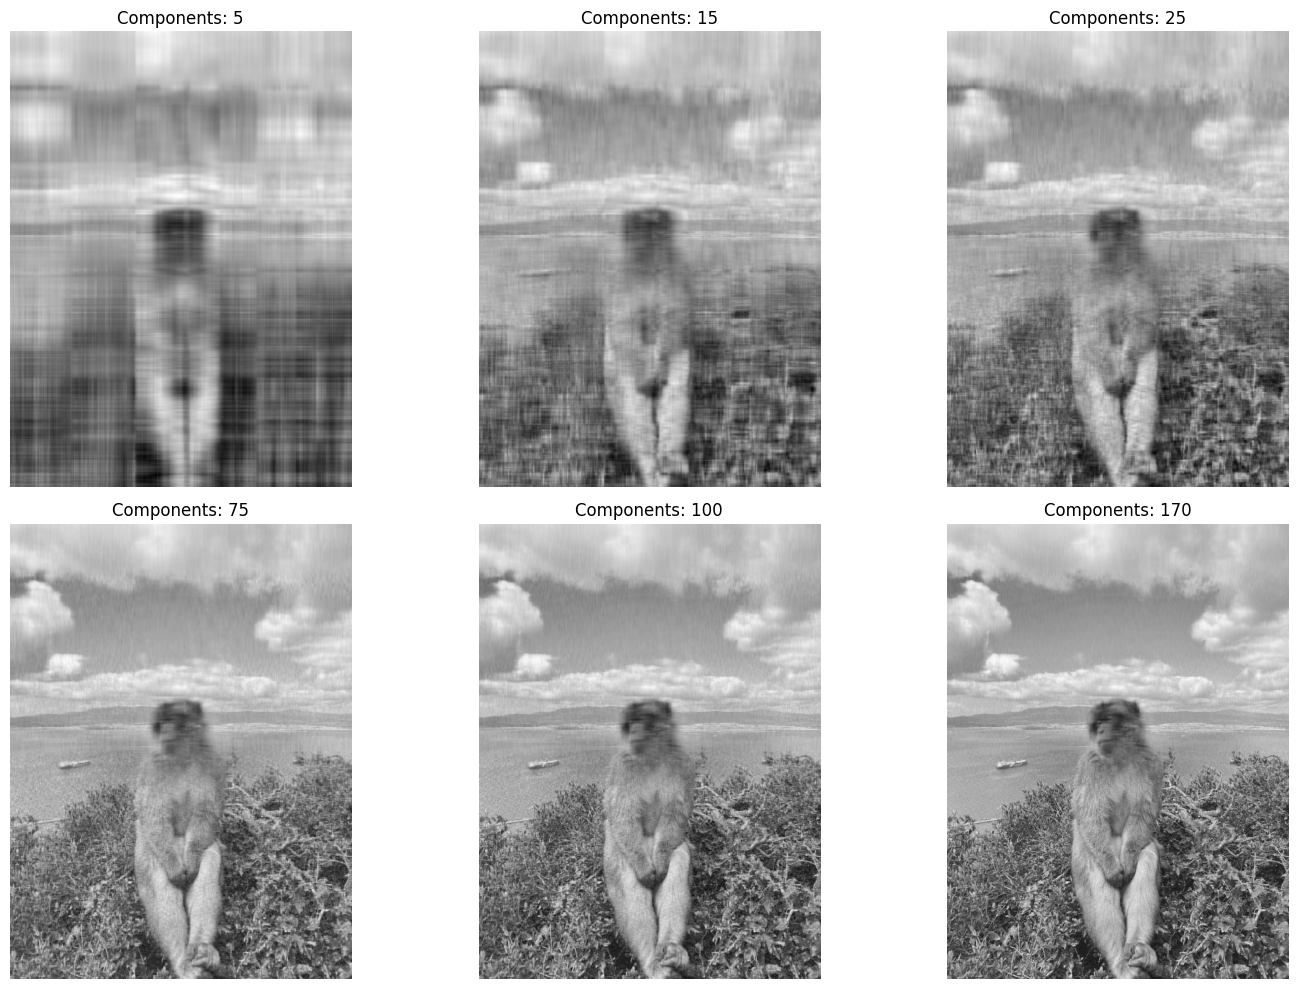

In [16]:
components_list = [5, 15, 25, 75, 100, 170]

plt.figure(figsize=(15,10))

for i, n in enumerate(components_list):
    pca_n = PCA(n_components=n)
    transformed = pca_n.fit_transform(image_bw)
    reconstructed = pca_n.inverse_transform(transformed)

    plt.subplot(2, 3, i + 1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"Components: {n}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Task 3**

In [26]:
def encrypt_message(message, key_matrix):
    message_vector = np.array([ord(char) for char in message])
    eigenvalues, eigenvectors = np.linalg.eig(key_matrix)
    diagonalized_key_matrix = np.dot(
        np.dot(eigenvectors, np.diag(eigenvalues)),
        np.linalg.inv(eigenvectors)
    )

    encrypted_vector = np.dot(diagonalized_key_matrix, message_vector)
    return encrypted_vector

In [27]:
def decrypt_message_(encrypted_vector, key_matrix):
    eigenvalues, eigenvectors = np.linalg.eig(key_matrix)

    diagonalized_key_matrix = np.dot(
        np.dot(eigenvectors, np.diag(eigenvalues)),
        np.linalg.inv(eigenvectors)
    )

    inverse_diagonalized_key_matrix = np.linalg.inv(diagonalized_key_matrix)
    decrypted_vector = np.dot(inverse_diagonalized_key_matrix, encrypted_vector)
    decrypted_message = "".join([chr(int(round(char))) for char in decrypted_vector])
    return decrypted_message

In [28]:
message = "Hello"
n = len(message)

key_matrix = np.eye(n) * 2
for i in range(n - 1):
    key_matrix[i, i + 1] = 1
    key_matrix[i + 1, i] = 1

encrypted_vector = encrypt_message(message, key_matrix)
decrypted_message = decrypt_message_(encrypted_vector, key_matrix)

print("Original Message:", message)
print("Encrypted Message:", encrypted_vector)
print("Decrypted Message:", decrypted_message)

Original Message: Hello
Encrypted Message: [245. 382. 425. 435. 330.]
Decrypted Message: Hello
